# Odejścia klientów w branży telekomunikacyjnej - porównanie klasyfikatorów

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/preprocessed_telco_customer_churn.csv", index_col=0)
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,...,internet_service_fiber_optic,internet_service_no,contract_month_to_month,contract_one_year,contract_two_year,payment_method_bank_transfer_automatic,payment_method_credit_card_automatic,payment_method_electronic_check,payment_method_mailed_check,churn
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,1,0,0
5575-GNVDE,1,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
3668-QPYBK,1,0,0,0,2,1,0,1,1,0,...,0,0,1,0,0,0,0,0,1,1
7795-CFOCW,1,0,0,0,45,0,0,1,0,1,...,0,0,0,1,0,1,0,0,0,0
9237-HQITU,0,0,0,0,2,1,0,0,0,0,...,1,0,1,0,0,0,0,1,0,1


#### Rozkład rezygnacji klientów

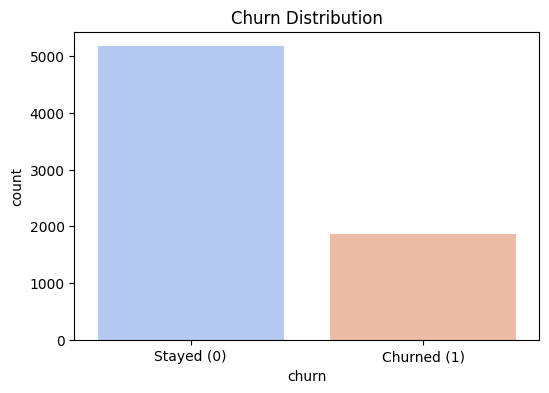

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, hue='churn', palette='coolwarm', legend=False)
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Stayed (0)', 'Churned (1)'])
plt.show()

Wykres pokazuje, że większość klientów pozostaje w firmie, a grupa osób odchodzących (churn) stanowi wyraźną mniejszość, co jest typowym układem dla tego problemu biznesowego.

#### Korelacja cech ze zmienną **churn** (odejście klienta)

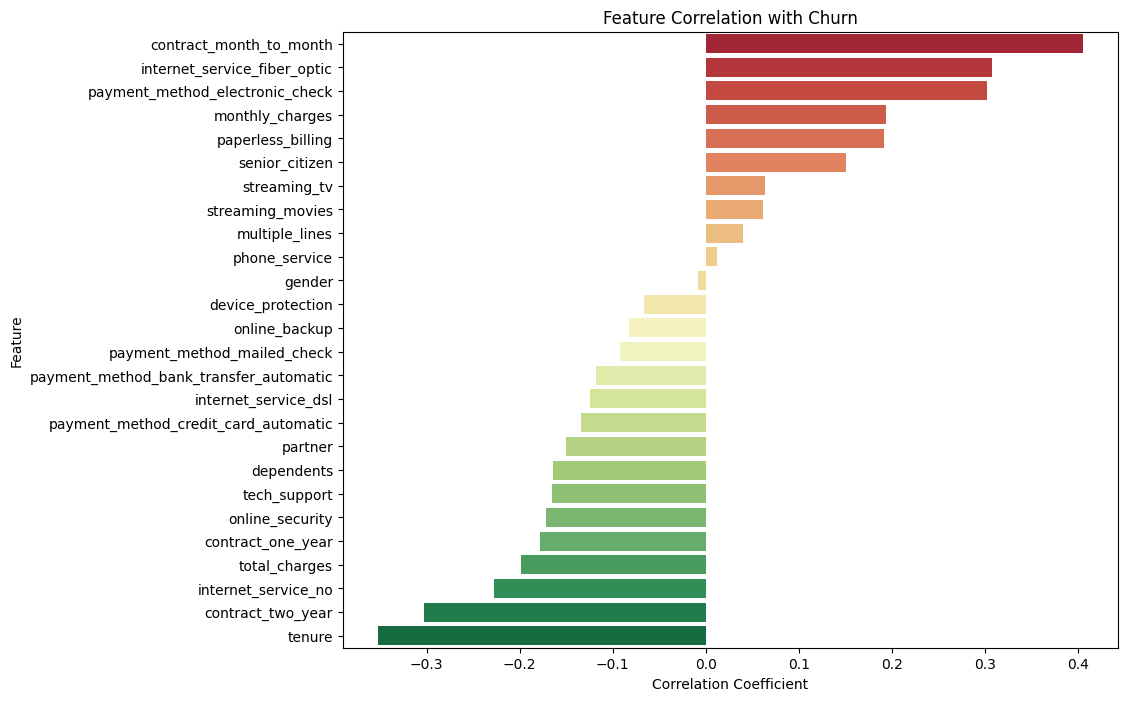

In [3]:
plt.figure(figsize=(10, 8))

churn_corr = df.corr()['churn'].drop('churn').sort_values(ascending=False)

sns.barplot(
    x=churn_corr.values, 
    y=churn_corr.index, 
    hue=churn_corr.index,
    palette='RdYlGn', 
    legend=False
)

plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.show()

Cechy na górze (kolor czerwony) mają dodatni związek z churn. Jeśli ta cecha występuje (wynosi 1), to prawdopodobieństwo odejścia klienta rośnie. Cechy na dole (kolor ciemnozielony) mają ujemny związek z churn. Jeśli ta cecha występuje (wynosi 1), tym mniejsza jest szansa na odejście klienta.

Wykres wskazuje, że najsilniejszymi czynnikami sprzyjającymi odejściu klienta są krótkoterminowe umowy (month-to-month) oraz korzystanie ze światłowodu i płatności czekiem elektronicznym. Z drugiej strony, długi staż pracy (tenure) oraz dwuletnie kontrakty najskuteczniej zatrzymują użytkowników w firmie. Cechy takie jak płeć czy posiadanie usługi telefonicznej mają znikomy wpływ na decyzję o rezygnacji.

#### Rozkład gęstości stażu klienta (tenure) względem rezygnacji

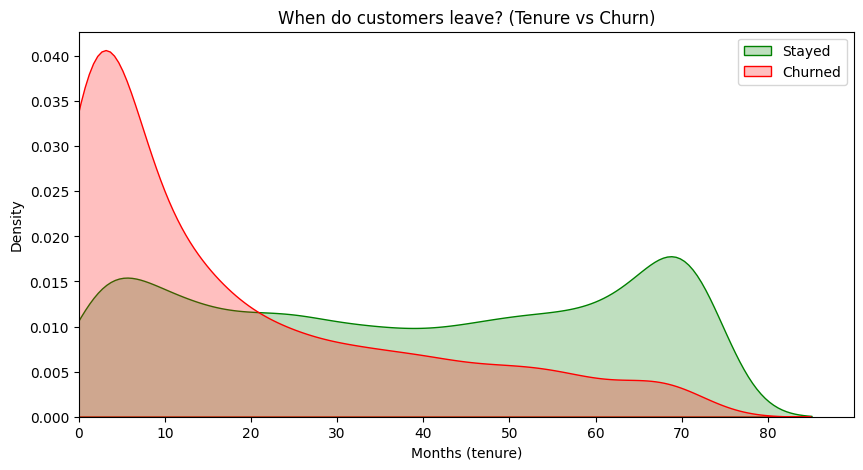

In [4]:
plt.figure(figsize=(10, 5))

sns.kdeplot(df[df['churn'] == 0]['tenure'], label='Stayed', fill=True, color='green')
sns.kdeplot(df[df['churn'] == 1]['tenure'], label='Churned', fill=True, color='red')

plt.title('When do customers leave? (Tenure vs Churn)')
plt.xlabel('Months (tenure)')
plt.ylabel('Density')
plt.xlim(0)
plt.ylim(0)
plt.legend()
plt.show()

Wykres gęstości ujawnia, że największe ryzyko odejścia występuje na samym początku relacji z klientem, o czym świadczy wyraźny czerwony szczyt w niskich wartościach stażu. Z kolei rozkład dla osób pozostających w firmie przesuwa się w stronę wysokich wartości, co potwierdza, że wraz z każdym kolejnym miesiącem prawdopodobieństwo, że klient zrezygnuje staje się coraz mniejsze.

#### Opłaty miesięczne a odejście

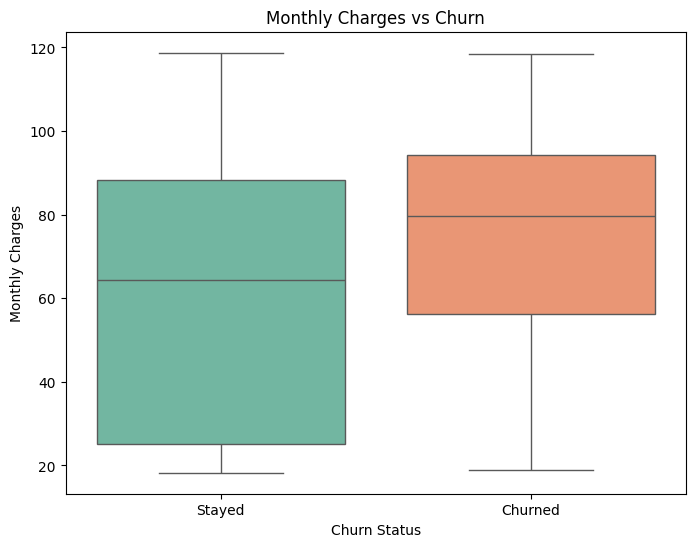

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='churn', y='monthly_charges', data=df, palette='Set2', hue='churn', legend=False)

plt.title('Monthly Charges vs Churn')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')
plt.show()

Pomarańczowe pole („Odeszli”) jest wyraźnie przesunięte w górę – mediana opłat wynosi tu ok. 80 jednostek, co oznacza, że rezygnują głównie klienci z droższymi pakietami.

Zielone pole („Zostali”) skupia się niżej, z medianą około 65 jednostek; pokazuje to, że tańsze usługi sprzyjają utrzymaniu klienta.

Widać wyraźnie, że wyższa cena usługi jest jednym z głównych czynników motywujących do rezygnacji.

## Analiza porównawcza klasyfikatorów binarnych

#### Proces składa się z trzech faz:

**1. Hyperparameter Tuning (Strojenie hiperparametrów)** – proces, podczas którego GridSearchCV lub RandomizedSearchCV szuka najlepszych ustawień dla każdego algorytmu.

**2. Model Validation (Walidacja modeli)** – sprawdzanie, jak algorytmy radzą sobie na danych, których wcześniej nie widziały (zbiór testowy).

**3. Model Selection (Wybór modelu)** – porównywanie metryk ($F1$, $Recall$, $AUC$), aby zdecydować, który algorytm najlepiej rozwiązuje problem biznesowy.

#### Podział zbioru na dane treningowe i testowe

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55, stratify=y)

print(X_train.shape)
print(X_test.shape)

(5634, 26)
(1409, 26)


### KNN - K-Najbliższych Sąsiadów (K-Nearest Neighbors)

Algorytm klasyfikacji oparty na zasadzie podobieństwa obiektów w przestrzeni cech.

**Działanie algorytmu:**

- **Identyfikacja sąsiadów:** Dla każdego nowego punktu algorytm wyszukuje $k$ najbliższych rekordów ze zbioru treningowego.
- **Głosowanie większościowe:** Klasa nowego punktu jest ustalana na podstawie dominującej klasy wśród jego $k$ najbliższych sąsiadów.
- **Metryka odległości:** Podobieństwo obliczane jest zazwyczaj za pomocą odległości euklidesowej.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, RocCurveDisplay

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), ['tenure', 'monthly_charges', 'total_charges'])],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])


param_grid = {'knn__n_neighbors': range(1, 70)}
grid = GridSearchCV(pipeline, param_grid, cv=skf, scoring='f1')

grid.fit(X_train, y_train)

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

print("--- KNN ---")
print(f"Best score for n_neighbors = {grid.best_params_['knn__n_neighbors']}")
print(f"Best F1 score: {grid.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nReport:")
print(classification_report(y_test, y_pred))

--- KNN ---
Best score for n_neighbors = 63
Best F1 score: 0.5891
Test accuracy: 0.8062

Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1035
           1       0.64      0.61      0.62       374

    accuracy                           0.81      1409
   macro avg       0.75      0.74      0.75      1409
weighted avg       0.80      0.81      0.80      1409



W analizie skuteczności modelu skupiono się na zdolności algorytmu do poprawnego rozróżnienia dwóch grup klientów: tych, którzy pozostają w firmie oraz tych, którzy rezygnują z usług.

#### 1. Klasa lojalna (0 – "Non-churn")
Model wykazuje bardzo wysoką stabilność w rozpoznawaniu klientów, którzy nie planują rezygnacji z usług:
- **Precision (0.86)**: Oznacza, że jeśli model przewiduje pozostanie klienta w firmie, ma rację w 86% przypadków.
- **Recall (0.88)**: Model poprawnie identyfikuje 88% wszystkich lojalnych klientów. Świadczy to o niskim ryzyku błędnego zakwalifikowania stabilnego klienta jako osoby „zagrożonej”.
- **F1-score (0.87)**: Wysoka średnia harmoniczna potwierdza, że model niemal bezbłędnie opisuje profil typowego, lojalnego klienta.

#### 2. Klasa zagrożona (1 – „Churn”)
W obszarze kluczowym z perspektywy biznesowej, wyniki modelu KNN wskazują na istotne ograniczenia:
- **Precision (0.64)**: Tylko 64% alarmów o odejściu klienta jest trafnych. Pozostałe 36% to „fałszywe alarmy”, które mogą generować niepotrzebne koszty akcji retencyjnych (np. oferowanie zniżek osobom, które i tak by zostały).
- **Recall (0.61)**: Jest to krytyczny parametr. Model wykrywa jedynie 61% faktycznych odejść. Oznacza to, że co drugi klient rezygnujący z usług pozostaje niewykryty przez algorytm, co uniemożliwia podjęcie działań zapobiegawczych.
- **F1-score (0.62)**: Wynik ten obrazuje niską efektywność modelu w balansowaniu między trafnością a czułością dla klasy Churn.


Model KNN, mimo wysokiej ogólnej dokładności (Test accuracy: 80.62%), charakteryzuje się niewystarczającą zdolnością predykcyjną w klasie mniejszościowej. Z perspektywy biznesowej, niski poziom Recall (0.61) jest nieakceptowalny, gdyż model pomija około 40% realnych odejść.

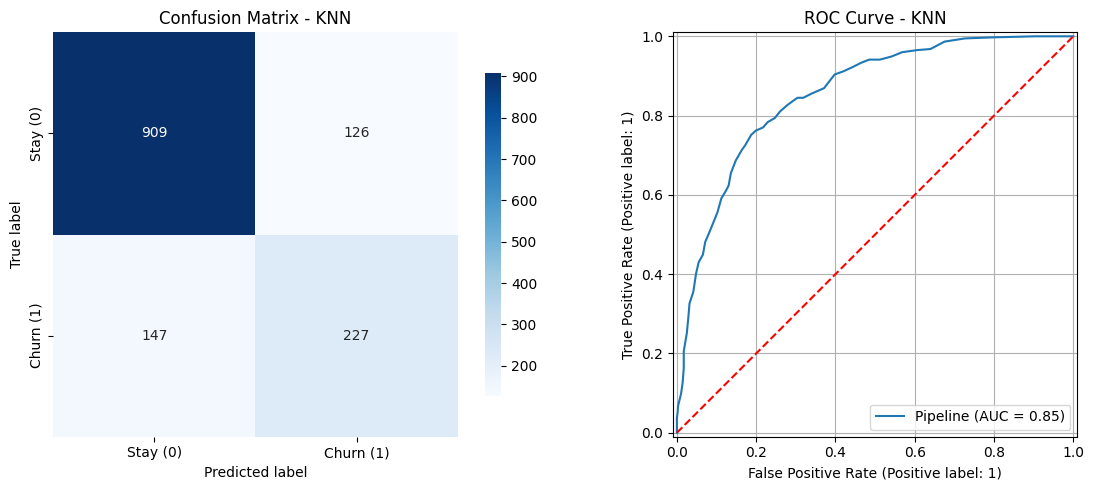

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar_kws={"shrink": .8},
            xticklabels=['Stay (0)', 'Churn (1)'], 
            yticklabels=['Stay (0)', 'Churn (1)'], ax=ax1)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')
ax1.set_title('Confusion Matrix - KNN')

RocCurveDisplay.from_estimator(best_knn, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_title('ROC Curve - KNN')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

Wykres macierzy pomyłek (Confusion Matrix) pokazuje, że model KNN poprawnie zidentyfikował 909 lojalnych klientów oraz 227 osób odchodzących, jednak błędnie zaklasyfikował 147 faktycznych odejść jako osoby zostające w firmie, co potwierdza jego niską skuteczność w wykrywaniu realnego zagrożenia rezygnacją (Churn).

Wykres krzywej ROC z wynikiem AUC na poziomie 0.85 potwierdza bardzo dobrą zdolność modelu KNN do rozróżniania klientów odchodzących od lojalnych, co wskazuje na jego wysoki potencjał analityczny mimo konieczności dopracowania czułości (Recall) w praktycznym zastosowaniu.

### Regresja Logistyczna (Logistic Regression)

Model statystyczny służący do wyznaczania prawdopodobieństwa przynależności do danej klasy za pomocą funkcji matematycznej.

**Działanie algorytmu:**

- **Funkcja logistyczna (Sigmoid):** Przekształca wynik liniowej kombinacji cech na wartość z przedziału od 0 do 1, reprezentującą prawdopodobieństwo.
- **Próg decyzyjny:** Na podstawie obliczonego prawdopodobieństwa model przypisuje rekord do klasy 0 lub 1 (domyślnie przy progu 0.5).
- **Optymalizacja wag:** Algorytm dopasowuje współczynniki dla każdej cechy tak, aby zminimalizować błąd przewidywań na zbiorze treningowym.

In [9]:
from sklearn.linear_model import LogisticRegression

log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression())
])

param_grid_log = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__class_weight': [None, 'balanced'],
    'logreg__solver': ['liblinear', 'lbfgs']
}

grid_log = GridSearchCV(log_pipeline, param_grid_log, cv=skf, scoring='f1')
grid_log.fit(X_train, y_train)

best_logreg = grid_log.best_estimator_
y_pred_log = best_logreg.predict(X_test)

print("--- Logistic Regression ---")
print(f"Best parameters: {grid_log.best_params_}")
print(f"Best F1 score (train): {grid_log.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

print("\nReport:")
print(classification_report(y_test, y_pred_log))

--- Logistic Regression ---
Best parameters: {'logreg__C': 0.1, 'logreg__class_weight': 'balanced', 'logreg__solver': 'lbfgs'}
Best F1 score (train): 0.6261
Test accuracy: 0.7608

Report:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1035
           1       0.53      0.82      0.65       374

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



Model uzyskał najwyższą zdolność detekcji klasy pozytywnej (Recall: 0.82), co oznacza, że poprawnie zidentyfikował 82% wszystkich faktycznych przypadków odejścia klientów. Pomimo niższego wskaźnika Precision (0.53) skutkującego większą liczbą "fałszywych alarmów", model osiągnął najwyższą ogólną efektywność w balansowaniu tych metryk (F1-score: 0.65).

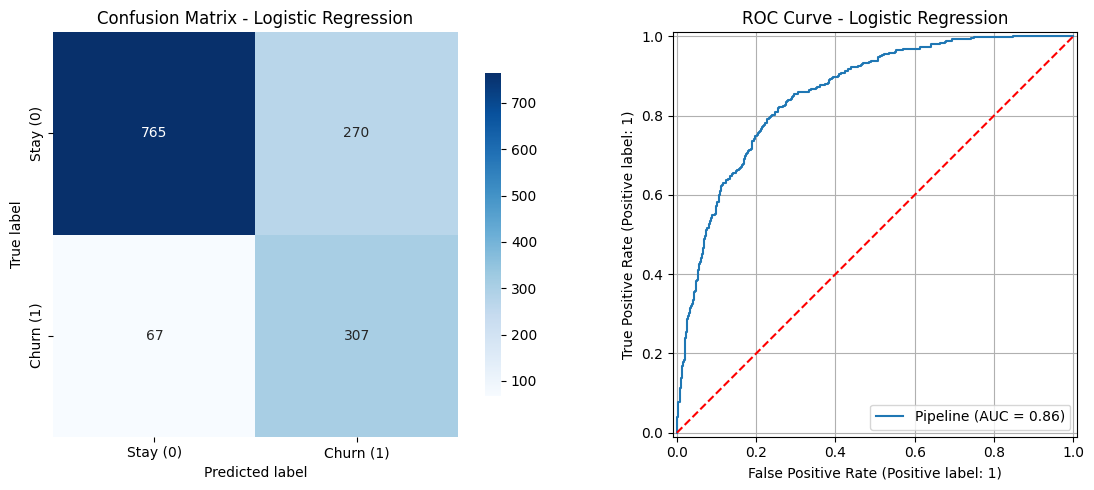

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar_kws={"shrink": .8},
            xticklabels=['Stay (0)', 'Churn (1)'], 
            yticklabels=['Stay (0)', 'Churn (1)'], ax=ax1)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')
ax1.set_title('Confusion Matrix - Logistic Regression')

RocCurveDisplay.from_estimator(best_logreg, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_title('ROC Curve - Logistic Regression')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

Wykres macierzy pomyłek pokazuje, że model poprawnie zidentyfikował 307 osób faktycznie odchodzących (True Positives) oraz 765 lojalnych klientów. Kluczowym aspektem jest znacząca redukcja błędów typu II – model przeoczył jedynie 67 odejść, co potwierdza jego wysoką zdolność do efektywnego wyłapywania większości klientów z grupy wysokiego ryzyka rezygnacji.

Wykres krzywej ROC z wynikiem AUC na poziomie 0.86 potwierdza wysoką skuteczność modelu w rozróżnianiu obu grup klientów. Wynik ten wskazuje, że Regresja Logistyczna bardzo dobrze radzi sobie z przypisywaniem wyższego prawdopodobieństwa odejścia osobom, które faktycznie rezygnują z usług, niż tym, które pozostają lojalne.

### Las Losowy (Random Forest)

Algorytm zespołowy oparty na budowie wielu drzew decyzyjnych i łączeniu ich wyników.

**Działanie algorytmu:**

- **Bagging (Bootstrap Aggregating):** Tworzy wiele podzbiorów danych poprzez losowanie ze zwracaniem, na których trenowane są osobne drzewa.
- **Losowanie cech:** Każde drzewo przy podziale węzła bierze pod uwagę tylko losowy podzbiór wszystkich dostępnych cech, co zwiększa różnorodność modeli.
- **Głosowanie zespołowe:** Ostateczna prognoza jest wynikiem większościowego głosowania wszystkich drzew w lesie.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier())
])

param_distributions_rf = {
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [None, 5, 10, 15, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': [None, 'balanced', 'balanced_subsample']
}

random_search_rf = RandomizedSearchCV(
    rf_pipeline, 
    param_distributions=param_distributions_rf, 
    n_iter=20, 
    cv=skf, 
    scoring='f1', 
    random_state=55,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

best_rf = random_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("--- Random Forest ---")
print(f"Best parameters: {random_search_rf.best_params_}")
print(f"Best F1 score (train): {random_search_rf.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nReport:")
print(classification_report(y_test, y_pred_rf))

--- Random Forest ---
Best parameters: {'rf__n_estimators': 500, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 4, 'rf__max_depth': 10, 'rf__class_weight': 'balanced_subsample'}
Best F1 score (train): 0.6313
Test accuracy: 0.7779

Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1035
           1       0.56      0.78      0.65       374

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.78      0.79      1409



Model Random Forest uzyskał stabilną skuteczność w identyfikacji obu grup klientów, osiągając wskaźnik F1-score na poziomie 0.65 dla klasy osób odchodzących. Wysoka czułość (Recall: 0.79) oznacza, że algorytm poprawnie wskazał 79% wszystkich faktycznych przypadków rezygnacji, przy zachowaniu ogólnej dokładności klasyfikacji (Accuracy) na poziomie 77.7%.

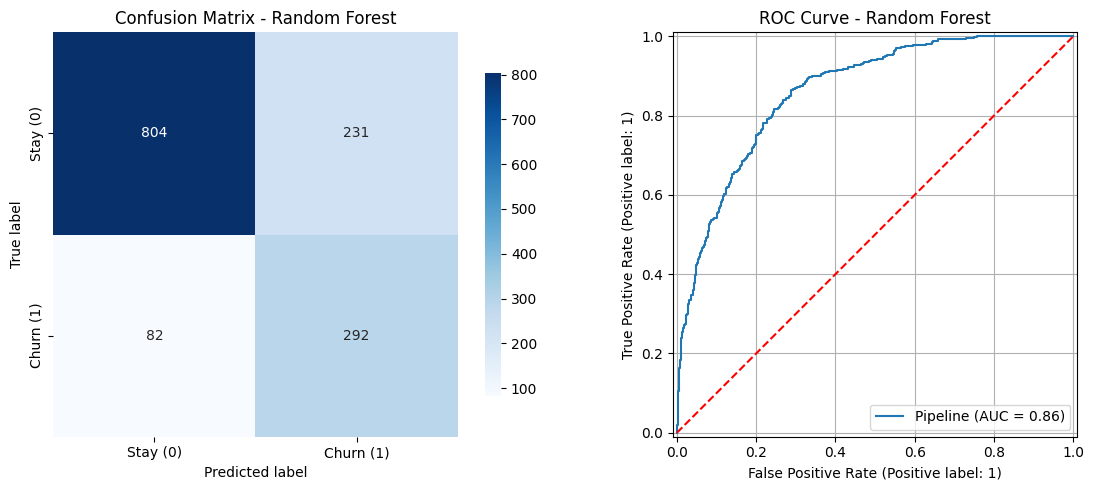

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar_kws={"shrink": .8},
            xticklabels=['Stay (0)', 'Churn (1)'], 
            yticklabels=['Stay (0)', 'Churn (1)'], ax=ax1)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')
ax1.set_title('Confusion Matrix - Random Forest')

RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_title('ROC Curve - Random Forest')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

Wykres pokazuje, że model poprawnie zidentyfikował 294 osoby faktycznie odchodzące oraz 801 lojalnych klientów. Błąd typu II wystąpił w 80 przypadkach, co oznacza, że algorytm skutecznie wyłapuje większość realnych rezygnacji, choć generuje przy tym zauważalną liczbę błędnych wskazań w grupie stabilnych klientów.

Wykres krzywej ROC z wynikiem AUC na poziomie 0.86 potwierdza wysoką skuteczność modelu w rozróżnianiu obu grup użytkowników. Wynik ten wskazuje, że Random Forest z dużym prawdopodobieństwem poprawnie różnicuje sygnały świadczące o chęci odejścia od zachowań typowych dla osób pozostających w firmie.

### Klasyfikator Naive Bayes

Klasyfikator probabilistyczny oparty na twierdzeniu Bayesa z założeniem o niezależności cech.

**Działanie algorytmu:**

- **Twierdzenie Bayesa:** Oblicza prawdopodobieństwo a posteriori wystąpienia klasy pod warunkiem zaobserwowania określonych cech.
- **Założenie "naiwne":** Zakłada, że każda cecha wpływa na wynik niezależnie od pozostałych, co upraszcza obliczenia.
- **Estymacja prawdopodobieństwa:** Model uczy się rozkładów częstotliwości wartości cech dla każdej klasy w celu późniejszej predykcji.

In [13]:
from sklearn.naive_bayes import GaussianNB

nb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('nb', GaussianNB())
])

param_grid_nb = {
    'nb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_nb = GridSearchCV(nb_pipeline, param_grid_nb, cv=skf, scoring='f1')
grid_nb.fit(X_train, y_train)

best_nb = grid_nb.best_estimator_
y_pred_nb = best_nb.predict(X_test)

print("--- Naive Bayes ---")
print(f"Best parameters: {grid_nb.best_params_}")
print(f"Best F1 score (train): {grid_nb.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")

print("\nReport:")
print(classification_report(y_test, y_pred_nb))

--- Naive Bayes ---
Best parameters: {'nb__var_smoothing': 1e-09}
Best F1 score (train): 0.6182
Test accuracy: 0.7516

Report:
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



Model Naive Bayes uzyskał solidny wynik F1-score (0.63), wykazując się bardzo wysoką czułością na poziomie 0.80. Oznacza to, że algorytm skutecznie identyfikuje aż 80% wszystkich osób odchodzących, choć dzieje się to kosztem niższej precyzji (0.52), co skutkuje sporą liczbą błędnych alarmów wśród lojalnych klientów.

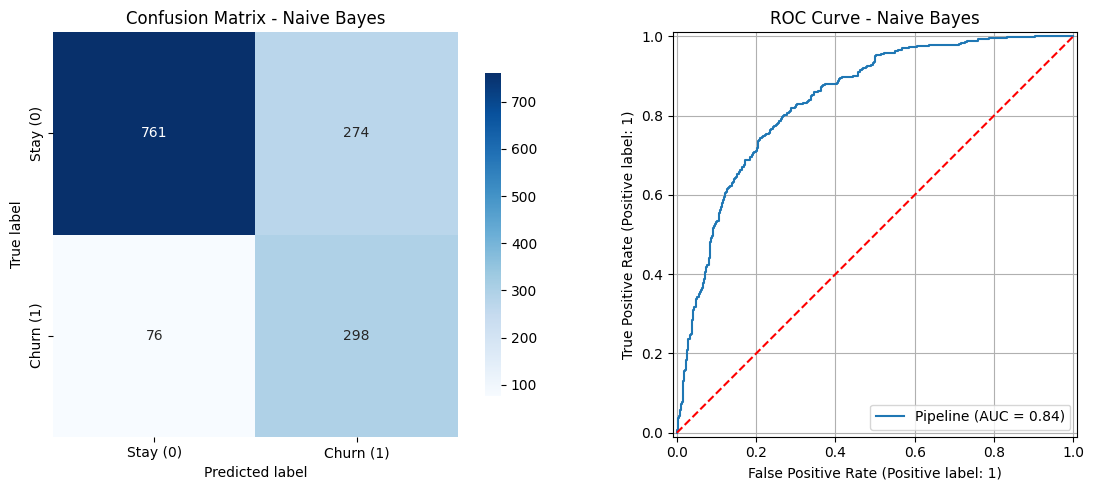

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar_kws={"shrink": .8},
            xticklabels=['Stay (0)', 'Churn (1)'], 
            yticklabels=['Stay (0)', 'Churn (1)'], ax=ax1)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')
ax1.set_title('Confusion Matrix - Naive Bayes')

RocCurveDisplay.from_estimator(best_nb, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_title('ROC Curve - Naive Bayes')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

Wykres macierzy pomyłek pokazuje, że model poprawnie zidentyfikował 298 osób faktycznie odchodzących oraz 761 lojalnych klientów. Błąd typu II wystąpił w 76 przypadkach, co oznacza, że algorytm skutecznie wyłapuje większość realnych rezygnacji, choć generuje przy tym zauważalną liczbę błędnych wskazań w grupie stabilnych klientów (274 przypadki).

Wskaźnik AUC = 0.84 potwierdza wysoką zdolność modelu do odróżniania klas, co czyni go użytecznym narzędziem do wczesnego wykrywania ryzyka odejścia klienta.

### Drzewo Decyzyjne (Decision Tree Classifier)

Model hierarchiczny, który dzieli zbiór danych na coraz mniejsze podgrupy na podstawie testów cech.

**Działanie algorytmu:**

- **Podział węzłów:** Algorytm wybiera cechę i próg, które najlepiej separują klasy (np. przy użyciu wskaźnika Giniego lub Entropii).
- **Struktura drzewiasta:** Tworzy sekwencję pytań "tak/nie", prowadzącą od korzenia przez gałęzie aż do liści (klas końcowych).
- **Rekurencyjne dzielenie:** Proces trwa do momentu osiągnięcia czystości węzła lub spełnienia ograniczeń (np. maksymalnej głębokości).

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier())
])

param_grid_dt = {
    'dt__max_depth': [None, 3, 5, 7, 10],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4],
    'dt__class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(dt_pipeline, param_grid_dt, cv=skf, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print("--- Decision Tree ---")
print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best F1 score (train): {grid_dt.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred_dt))

--- Decision Tree ---
Best parameters: {'dt__class_weight': 'balanced', 'dt__max_depth': 5, 'dt__min_samples_leaf': 4, 'dt__min_samples_split': 2}
Best F1 score (train): 0.6183
Test accuracy: 0.7289

Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.49      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.74      1409



Model drzewa decyzyjnego uzyskał wynik F1-score na poziomie 0.62, wykazując się bardzo wysoką czułością (Recall: 0.82). Oznacza to, że algorytm jest bardzo skuteczny w wykrywaniu osób realnie odchodzących z firmy, jednak robi to kosztem precyzji (0.49), co generuje dużą liczbę fałszywych alarmów (ponad połowa wskazań odejścia klienta jest błędna).

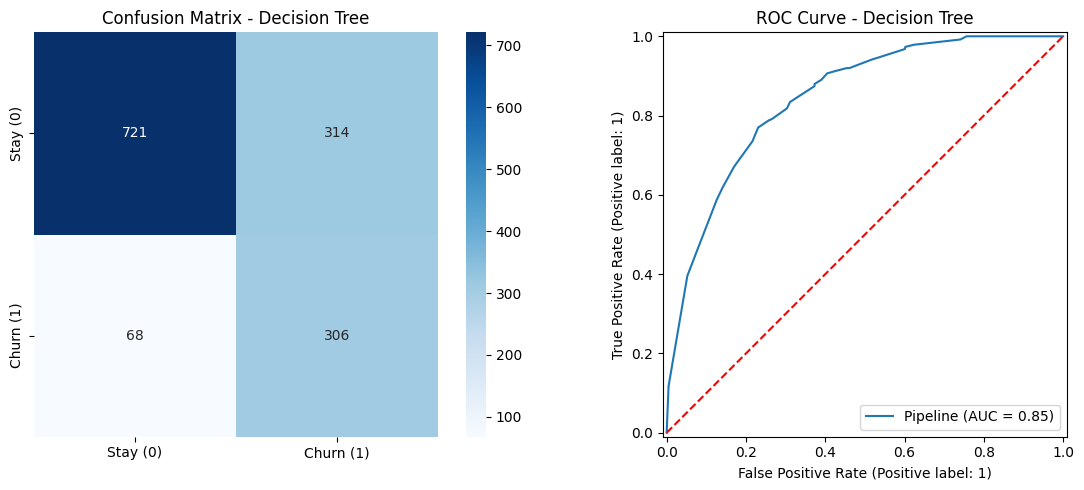

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, ax=ax1,
            xticklabels=['Stay (0)', 'Churn (1)'], yticklabels=['Stay (0)', 'Churn (1)'])
ax1.set_title('Confusion Matrix - Decision Tree')

RocCurveDisplay.from_estimator(best_dt, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_title('ROC Curve - Decision Tree')

plt.tight_layout()
plt.show()

Wykres pokazuje, że model poprawnie zidentyfikował 306 osób faktycznie odchodzących oraz 721 lojalnych klientów. Błąd typu II (przeoczenie odejścia) wystąpił jedynie w 68 przypadkach, co oznacza, że algorytm bardzo skutecznie wyłapuje większość realnych rezygnacji, choć generuje przy tym wysoką liczbę błędnych wskazań w grupie stabilnych klientów (314 przypadki).

Wynik AUC = 0.85 wskazuje na wysoki potencjał separacyjny modelu, jednak w zestawieniu z niską precyzją oznacza to, że model świetnie porządkuje klientów od najbardziej do najmniej zagrożonych odejściem, ale wymaga bardzo ostrożnego dobrania progu odcięcia, aby uniknąć nadmiernej liczby kosztownych, błędnych alarmów.

### XGBoost (Extreme Gradient Boosting)

Zaawansowany algorytm wzmacniania gradientowego, optymalizowany pod kątem szybkości i wydajności.

**Działanie algorytmu:**

- **Boosting sekwencyjny:** Buduje drzewa jedno po drugim, gdzie każde kolejne drzewo próbuje skorygować błędy popełnione przez poprzednie.
- **Funkcja celu z regularyzacją:** Minimalizuje błąd przewidywania, jednocześnie nakładając kary za zbyt skomplikowany model (zapobieganie overfittingowi).
- **Gradienty i Hesjany:** Wykorzystuje pochodne drugiego rzędu do precyzyjnego i szybkiego wyznaczania kierunku optymalizacji.

In [17]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(eval_metric='logloss'))
])

param_distributions_xgb = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 4, 5, 6],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8, 0.9],
    'xgb__scale_pos_weight': [1, 3, 5]
}

random_search_xgb = RandomizedSearchCV(
    xgb_pipeline, 
    param_distributions=param_distributions_xgb, 
    n_iter=20, 
    cv=skf, 
    scoring='f1', 
    random_state=55,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

best_xgb = random_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("--- XGBoost ---")
print(f"Best parameters: {random_search_xgb.best_params_}")
print(f"Best F1 score (train): {random_search_xgb.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred_xgb))

--- XGBoost ---
Best parameters: {'xgb__subsample': 0.9, 'xgb__scale_pos_weight': 3, 'xgb__n_estimators': 100, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.05}
Best F1 score (train): 0.6278
Test accuracy: 0.7580

Report:
              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1035
           1       0.53      0.83      0.65       374

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



Model XGBoost uzyskał wynik F1-score na poziomie 0.65, przy bardzo wysokiej czułości (Recall: 0.83). Oznacza to, że algorytm poprawnie identyfikuje 83% wszystkich faktycznych odejść klientów. Precyzja wynosząca 0.53 wskazuje na to, że model zachowuje akceptowalny balans między wykrywaniem rezygnacji a liczbą generowanych błędnych alarmów.

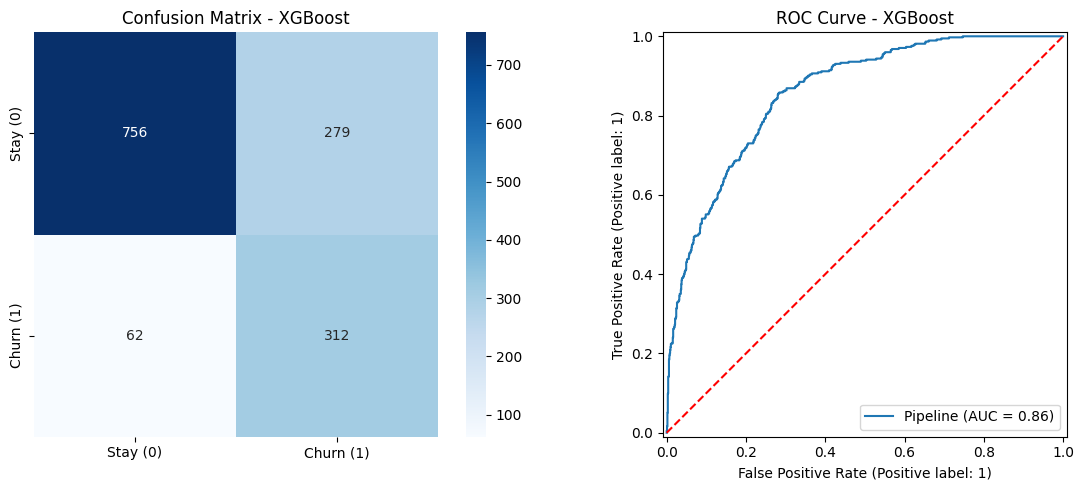

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, ax=ax1,
            xticklabels=['Stay (0)', 'Churn (1)'], yticklabels=['Stay (0)', 'Churn (1)'])
ax1.set_title('Confusion Matrix - XGBoost')

RocCurveDisplay.from_estimator(best_xgb, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_title('ROC Curve - XGBoost')

plt.tight_layout()
plt.show()

Wykres macierzy pomyłek pokazuje, że model poprawnie zidentyfikował 312 osób faktycznie odchodzących oraz 756 lojalnych klientów. Błąd typu II wystąpił w 62 przypadkach, co oznacza, że algorytm skutecznie wyłapuje dużą część realnych rezygnacji. Model wygenerował przy tym 279 błędnych wskazań w grupie stabilnych klientów.

Wskaźnik AUC = 0.86 potwierdza bardzo wysoką zdolność modelu do poprawnej separacji klas. Kształt krzywej sugeruje, że model precyzyjnie przypisuje wyższe prawdopodobieństwo osobom, które faktycznie decydują się na zakończenie współpracy.

### AdaBoost (Adaptive Boosting)

Klasyczny algorytm wzmacniania, który adaptacyjnie dostosowuje wagi próbek podczas treningu.

**Działanie algorytmu:**

- **Wzmacnianie słabych klasyfikatorów:** Łączy wiele bardzo prostych modeli (tzw. pieńków decyzyjnych) w jeden silny klasyfikator.
- **Aktualizacja wag:** Przykłady błędnie sklasyfikowane otrzymują większą wagę w kolejnej iteracji, wymuszając na modelu skupienie się na trudnych przypadkach.
- **Ważone głosowanie:** Modele o mniejszym błędzie mają większy wpływ na ostateczną decyzję klasyfikatora.

In [19]:
from sklearn.ensemble import AdaBoostClassifier

ada_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ada', AdaBoostClassifier(algorithm='SAMME'))
])

param_distributions_ada = {
    'ada__n_estimators': [50, 100, 200, 300],
    'ada__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

random_search_ada = RandomizedSearchCV(
    ada_pipeline, 
    param_distributions=param_distributions_ada, 
    n_iter=15, 
    cv=skf, 
    scoring='f1', 
    random_state=55,
    n_jobs=-1
)

random_search_ada.fit(X_train, y_train)

best_ada = random_search_ada.best_estimator_
y_pred_ada = best_ada.predict(X_test)

print("--- AdaBoost ---")
print(f"Best parameters: {random_search_ada.best_params_}")
print(f"Best F1 score (train): {random_search_ada.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")

print("\nReport:")
print(classification_report(y_test, y_pred_ada))

--- AdaBoost ---
Best parameters: {'ada__n_estimators': 100, 'ada__learning_rate': 1.0}
Best F1 score (train): 0.5721
Test accuracy: 0.8119

Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1035
           1       0.68      0.54      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Model AdaBoost charakteryzuje się wysoką ogólną dokładnością (Accuracy: 0.81), jednak wykazuje trudności w precyzyjnym typowaniu klientów odchodzących, co potwierdza umiarkowany wynik F1-score (0.61). Przy czułości (Recall) na poziomie 0.54, algorytm poprawnie identyfikuje jedynie nieco ponad połowę faktycznych przypadków Churn, co sugeruje, że model ten stawia wyżej poprawność klasyfikacji klientów lojalnych niż wykrywanie rezygnacji.

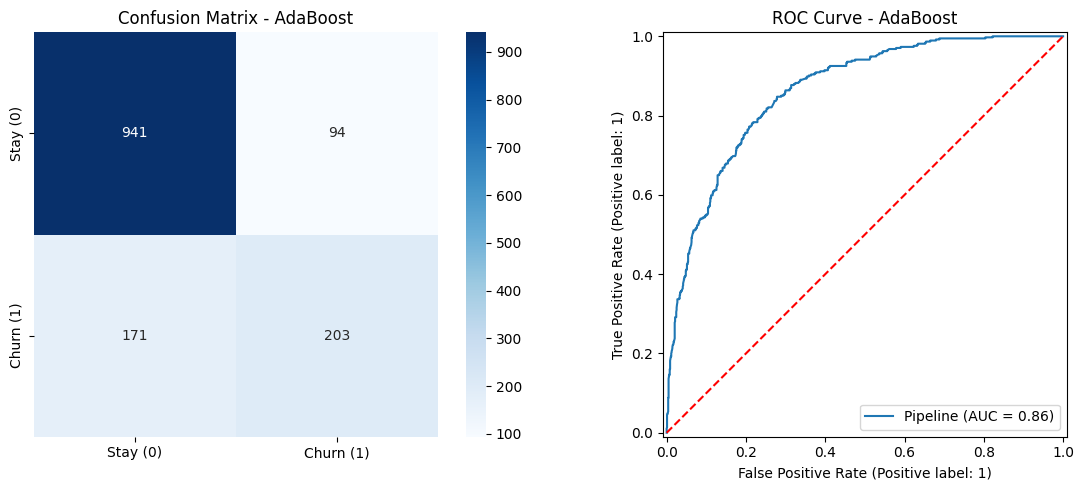

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, ax=ax1,
            xticklabels=['Stay (0)', 'Churn (1)'], yticklabels=['Stay (0)', 'Churn (1)'])
ax1.set_title('Confusion Matrix - AdaBoost')

RocCurveDisplay.from_estimator(best_ada, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_title('ROC Curve - AdaBoost')

plt.tight_layout()
plt.show()

Wykres macierzy pomyłek pokazuje, że model poprawnie zidentyfikował 203 osoby faktycznie odchodzące oraz 941 lojalnych klientów. Błąd typu II wystąpił w 171 przypadkach, co oznacza, że algorytm przeoczył znaczną część realnych rezygnacji. Z drugiej strony, model wygenerował relatywnie niską liczbę błędnych wskazań w grupie stabilnych klientów (94 przypadki).

Wskaźnik AUC = 0.86 świadczy o dużym potencjale modelu do rozróżniania klas. Wysoka wartość tego parametru sugeruje, że choć przy domyślnym progu klasyfikacji czułość jest niska, odpowiednia kalibracja modelu mogłaby znacząco poprawić jego skuteczność w wykrywaniu odejść klientów.

### Podsumowanie i wnioski, gdy użyto standardowego progu decyzyjnego dla oceny modeli

Poniższa tabela zestawia kluczowe metryki wszystkich przetestowanych modeli dla klasy mniejszościowej (Churn) przy domyślnym progu decyzyjnym.

| Model | Accuracy | Precision | Recall | F1-Score |
| :--- | :---: | :---: | :---: | :---: |
| **KNN** | 0.8062 | 0.64 | 0.61 | 0.62 |
| **Logistic Regression** | 0.7608 | 0.53 | 0.82 | **0.65** |
| **Random Forest** | 0.7750 | 0.55 | 0.78 | **0.65** |
| **Naive Bayes** | 0.7516 | 0.52 | 0.80 | 0.63 |
| **Decision Tree** | 0.7289 | 0.49 | 0.82 | 0.62 |
| **XGBoost** | 0.7580 | 0.53 | **0.83** | **0.65** |
| **AdaBoost** | **0.8119** | **0.68** | 0.54 | 0.61 |

#### Kluczowe wnioski:

* **Najwyższa ogólna trafność (Accuracy):** Najwyższy wynik uzyskał **AdaBoost** (0.8119) oraz **KNN** (0.8062), co wynika z ich bardzo dobrej skuteczności w klasyfikowaniu osób, które nie odchodzą.
* **Skuteczność wykrywania odejść (Recall):** Najlepiej w identyfikowaniu zagrożonych klientów radzi sobie **XGBoost** (0.83), co oznacza, że wyłapuje on najwięcej faktycznych przypadków rezygnacji.
* **Precyzja wskazań (Precision):** Jeśli zależy nam na pewności, że wskazany klient rzeczywiście odejdzie, przoduje **AdaBoost** (0.68).
* **Balans metryk (F1-Score):** Najwyższy i najbardziej stabilny wynik (0.65) dzielą między sobą **XGBoost**, **Logistic Regression** oraz **Random Forest**.


Mimo najwyższego Accuracy modelu AdaBoost, w kontekście biznesowym (minimalizacja odejść) rekomenduje się **XGBoost**. Posiada on najwyższą czułość (*Recall*) przy solidnym wyniku *F1-Score*, co pozwala na objęcie działaniami retencyjnymi największej liczby realnie zagrożonych klientów.

## Optymalizacja progu decyzyjnego i ewaluacja końcowa modeli

Standardowe modele klasyfikacyjne przyjmują próg odcięcia na poziomie 0.5, co nie zawsze jest optymalne przy niezbalansowanych zbiorach danych. W tej sekcji stosujemy metodę przesunięcia progu decyzyjnego (Threshold Moving), aby znaleźć punkt, który najlepiej balansuje precyzję i czułość, maksymalizując metrykę F1-Score pod kątem biznesowym.


MODEL: KNN
Optimal Decision Threshold: 0.4127

Classification Report (After Threshold Optimization):
              precision    recall  f1-score   support

           0       0.90      0.81      0.85      1035
           1       0.59      0.75      0.66       374

    accuracy                           0.80      1409
   macro avg       0.75      0.78      0.76      1409
weighted avg       0.82      0.80      0.80      1409



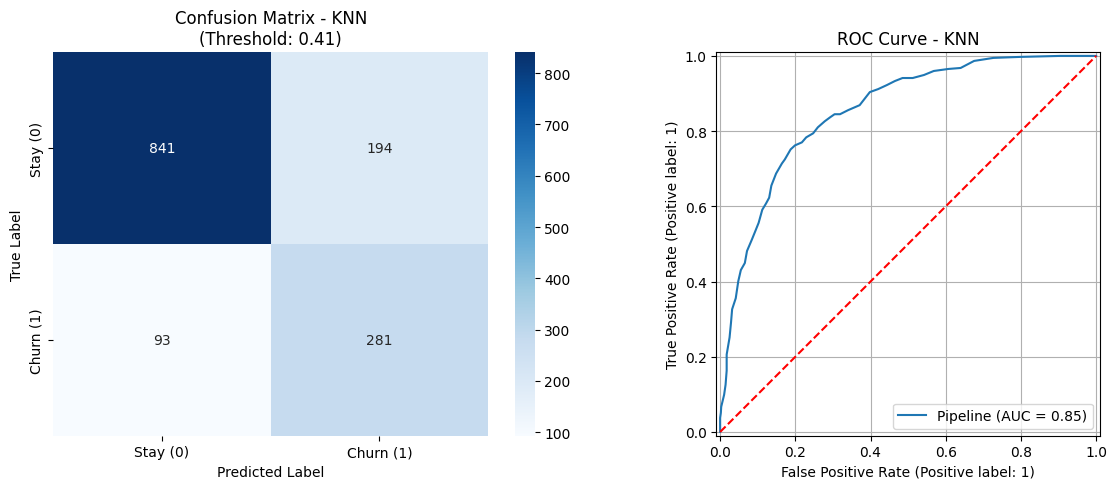


MODEL: Logistic Regression
Optimal Decision Threshold: 0.5482

Classification Report (After Threshold Optimization):
              precision    recall  f1-score   support

           0       0.91      0.77      0.84      1035
           1       0.56      0.79      0.65       374

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.78      0.79      1409



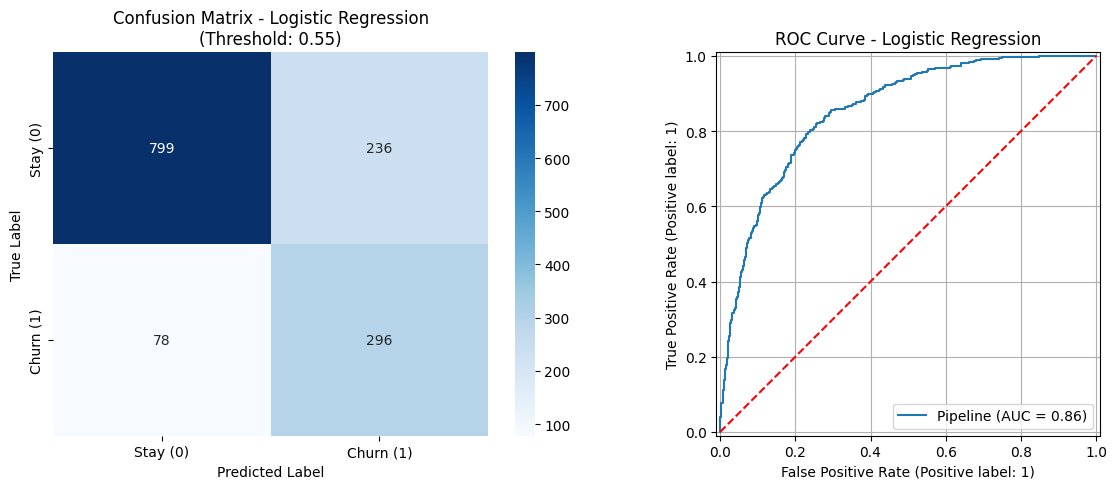


MODEL: Random Forest
Optimal Decision Threshold: 0.5047

Classification Report (After Threshold Optimization):
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1035
           1       0.56      0.78      0.65       374

    accuracy                           0.78      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.78      0.79      1409



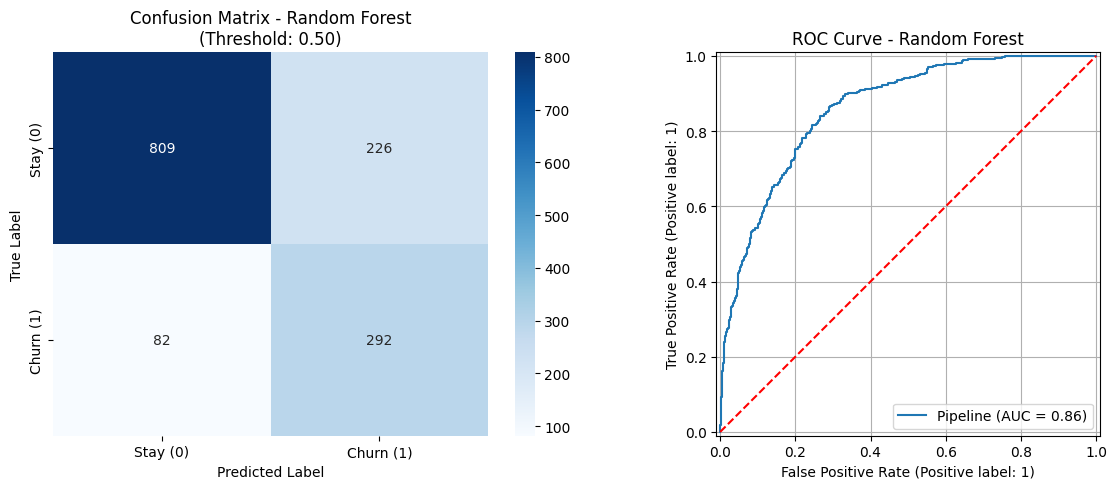


MODEL: Naive Bayes
Optimal Decision Threshold: 0.8378

Classification Report (After Threshold Optimization):
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.74      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



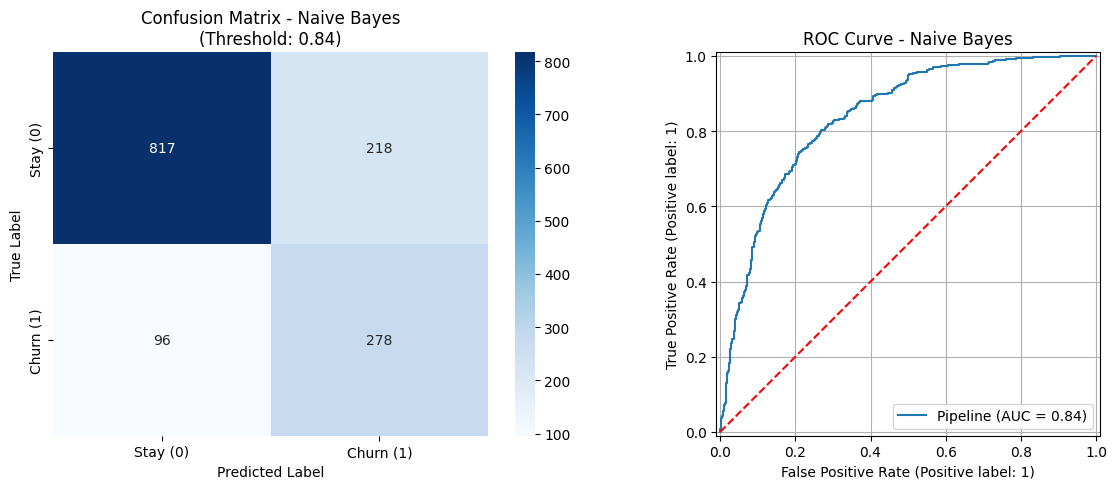


MODEL: Decision Tree
Optimal Decision Threshold: 0.5938

Classification Report (After Threshold Optimization):
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.55      0.77      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



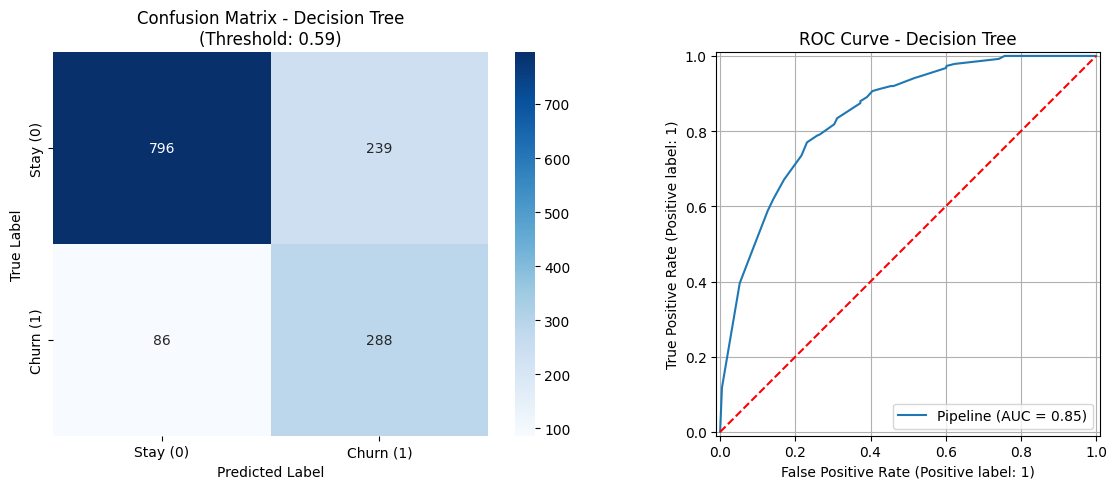


MODEL: XGBoost
Optimal Decision Threshold: 0.4717

Classification Report (After Threshold Optimization):
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1035
           1       0.52      0.86      0.65       374

    accuracy                           0.76      1409
   macro avg       0.73      0.79      0.73      1409
weighted avg       0.82      0.76      0.77      1409



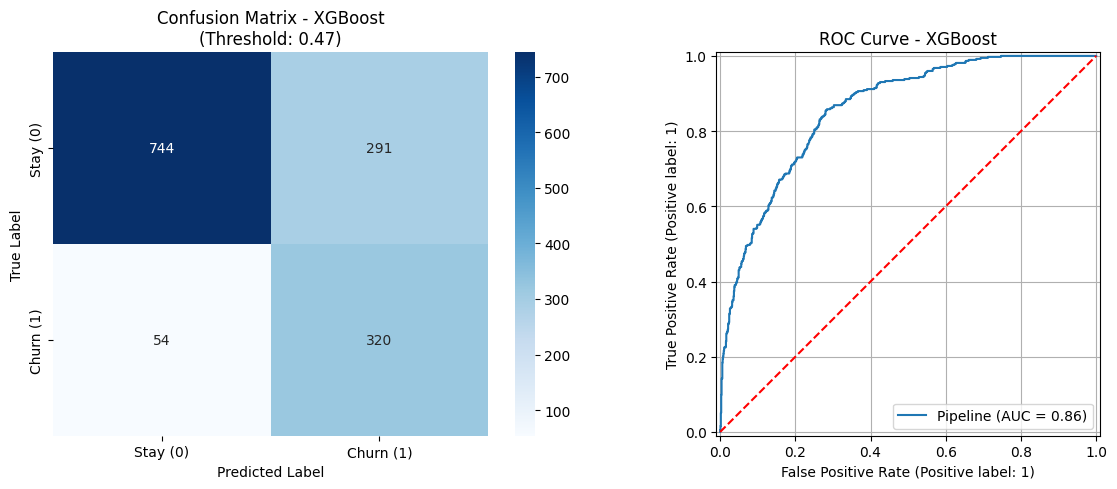


MODEL: AdaBoost
Optimal Decision Threshold: 0.4545

Classification Report (After Threshold Optimization):
              precision    recall  f1-score   support

           0       0.91      0.79      0.84      1035
           1       0.57      0.77      0.66       374

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.79      0.80      1409



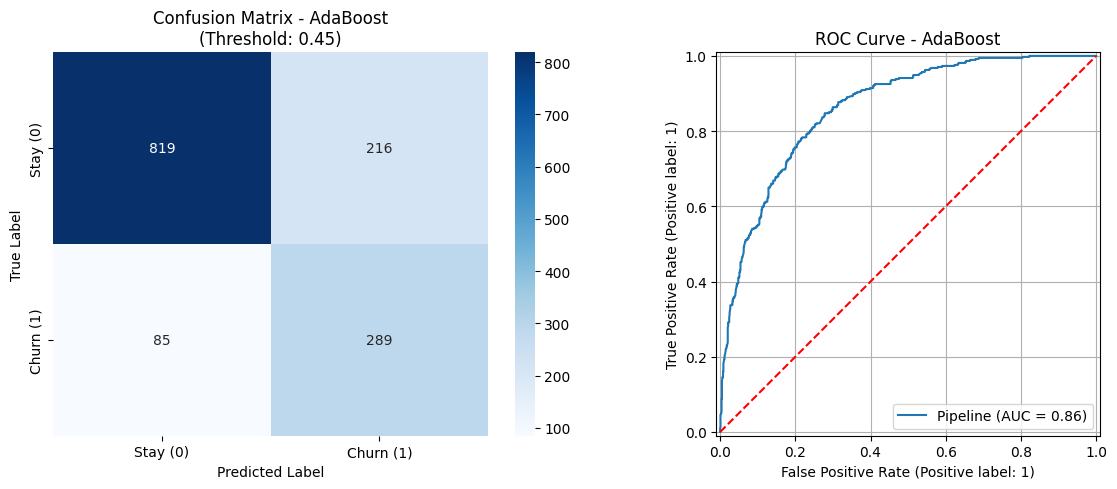


--- Aggregate Model Performance Summary ---
                 Model  Best Threshold  F1-Score
0                  KNN          0.4127    0.6620
6             AdaBoost          0.4545    0.6576
2        Random Forest          0.5047    0.6547
1  Logistic Regression          0.5482    0.6534
5              XGBoost          0.4717    0.6497
4        Decision Tree          0.5938    0.6393
3          Naive Bayes          0.8378    0.6391


In [26]:
import numpy as np
from sklearn.metrics import precision_recall_curve

models = {
    "KNN": best_knn,
    "Logistic Regression": best_logreg,
    "Random Forest": best_rf,
    "Naive Bayes": best_nb,
    "Decision Tree": best_dt,
    "XGBoost": best_xgb,
    "AdaBoost": best_ada
}

results = []

for name, model in models.items():
    print(f"\n{'='*30}")
    print(f"MODEL: {name}")
    print(f"{'='*30}")
    
    y_probs = model.predict_proba(X_test)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    f1_scores = np.divide(2 * precision * recall, precision + recall, 
                          out=np.zeros_like(precision), where=(precision + recall) != 0)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    y_pred_adj = (y_probs >= best_threshold).astype(int)
    
    print(f"Optimal Decision Threshold: {best_threshold:.4f}")
    print("\nClassification Report (After Threshold Optimization):")
    print(classification_report(y_test, y_pred_adj))
    
    results.append({
        "Model": name,
        "Best Threshold": round(best_threshold, 4),
        "F1-Score": round(f1_scores[best_idx], 4)
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    cm = confusion_matrix(y_test, y_pred_adj)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Stay (0)', 'Churn (1)'], yticklabels=['Stay (0)', 'Churn (1)'])
    ax1.set_title(f'Confusion Matrix - {name}\n(Threshold: {best_threshold:.2f})')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')

    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax2)
    ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
    ax2.set_title(f'ROC Curve - {name}')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

summary_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\n--- Aggregate Model Performance Summary ---")
print(summary_df)

Zastosowanie metody przesunięcia progu decyzyjnego pozwoliło na drastyczne wyrównanie szans między modelami. Dzięki optymalizacji punktu odcięcia pod kątem metryki F1-Score, modele, które wcześniej wypadały gorzej (jak KNN czy Naive Bayes), osiągnęły wyniki niemal identyczne z zaawansowanymi algorytmami typu Boosting.

### Podsumowanie i wnioski po optymalizacji progu decyzyjnego

W celu maksymalizacji balansu między precyzją a czułością, dla każdego modelu wyznaczono optymalny próg decyzyjny (maksymalizujący F1-Score).

| Model | Best Threshold | Accuracy | Recall | F1-Score |
| :--- | :---: | :---: | :---: | :---: |
| **KNN** | 0.4127 | **0.80** | 0.75 | **0.6620** |
| **AdaBoost** | 0.4545 | 0.79 | 0.77 | 0.6576 |
| **Random Forest** | 0.5047 | 0.78 | 0.78 | 0.6547 |
| **Logistic Regression** | 0.5482 | 0.78 | 0.79 | 0.6534 |
| **XGBoost** | 0.4717 | 0.76 | **0.86** | 0.6497 |
| **Decision Tree** | 0.5938 | 0.77 | 0.77 | 0.6393 |
| **Naive Bayes** | 0.8378 | 0.78 | 0.74 | 0.6391 |

#### Kluczowe wnioski:

* **KNN nowym liderem balansu:** Dzięki obniżeniu progu do 0.41, model **KNN** uzyskał najwyższy wynik **F1-Score (0.6620)**, co czyni go najbardziej zrównoważonym modelem w zestawieniu po tuningu.
* **Maksymalna czułość (Recall):** Model **XGBoost** po optymalizacji progu osiągnął najwyższy **Recall (0.86)**. W kontekście biznesowym oznacza to wykrycie aż 86% realnie odchodzących klientów.
* **Wyrównanie stawki:** Optymalizacja progów pozwoliła "słabszym" wcześniej modelom (jak KNN czy AdaBoost) dorównać skutecznością do XGBoosta, znacząco podnosząc ich przydatność w wykrywaniu rezygnacji.


Po uwzględnieniu optymalizacji progu decyzyjnego, rekomenduje się wybór modelu **KNN** ze względu na najwyższy wskaźnik F1-Score. Jeśli jednak priorytetem firmy jest minimalizacja odejść i objęcie działaniami retencyjnymi jak największej grupy realnie zagrożonych osób, najlepszym wyborem pozostaje **XGBoost** z rekordowym wynikiem Recall na poziomie 0.86.